### Importing Modules

In [21]:
import numpy as np
import matplotlib.pyplot as plt

### Parameters

In [22]:
N = 1000
beta = 0.3
gamma = 0.1

# Initial values
S0, I0, R0 = 999, 1, 0



### Gillespie Algorithm Implementation

In [23]:
def gillespie_sir(N, beta, gamma, S0, I0, R0, T_max):
    # Initial state
    S, I, R = S0, I0, R0
    t = 0

    # Store results
    time = [t]
    S_list = [S]
    I_list = [I]
    R_list = [R]

    while t < T_max and I > 0:
        # Rates
        R1 = beta * S * I / N      # infection
        R2 = gamma * I            # recovery
        R_total = R1 + R2

        if R_total == 0:
            break

        # Time to next event
        U1 = np.random.rand()
        tau = -np.log(U1) / R_total
        t += tau

        # Decide event
        U2 = np.random.rand()
        if U2 < R1 / R_total:
            # Infection event
            if S > 0:
                S -= 1
                I += 1
        else:
            # Recovery event
            if I > 0:
                I -= 1
                R += 1

        # Store
        time.append(t)
        S_list.append(S)
        I_list.append(I)
        R_list.append(R)

    return time, S_list, I_list, R_list

### Run Simulation

In [24]:
time, S, I, R = gillespie_sir(N, beta, gamma, S0, I0, R0, T_max=160)

### Plotting Results

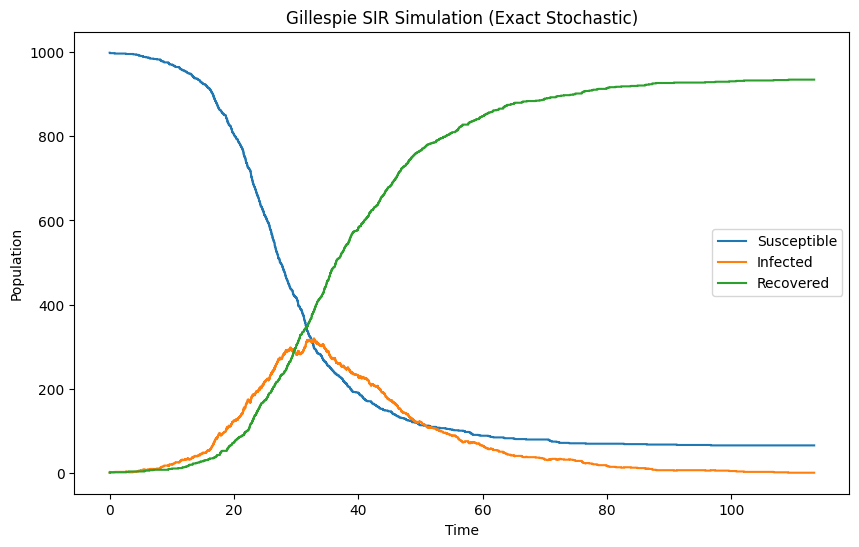

In [25]:
plt.figure(figsize=(10,6))
plt.step(time, S, label='Susceptible')
plt.step(time, I, label='Infected')
plt.step(time, R, label='Recovered')

plt.xlabel("Time")
plt.ylabel("Population")
plt.legend()
plt.title("Gillespie SIR Simulation (Exact Stochastic)")
plt.show()

### Using the SIRStochasticModel Class

The `sir_model.py` module wraps the Gillespie algorithm in a reusable class with save/load support.

In [ ]:
from sir_model import SIRStochasticModel

# Instantiate with default parameters
model = SIRStochasticModel(N=N, beta=beta, gamma=gamma)
print(model)


### Single Simulation via Class

In [ ]:
result = model.simulate(S0, I0, R0, T_max=160, seed=0)

plt.figure(figsize=(10, 5))
plt.step(result["time"], result["S"], label="Susceptible")
plt.step(result["time"], result["I"], label="Infected")
plt.step(result["time"], result["R"], label="Recovered")
plt.xlabel("Time"); plt.ylabel("Population")
plt.title("Gillespie SIR Simulation (SIRStochasticModel)")
plt.legend()
plt.show()


### Mean Trajectory over Multiple Runs

In [ ]:
mean_result = model.simulate_mean(S0, I0, R0, T_max=160, n_runs=50, seed=42)

plt.figure(figsize=(10, 5))
for comp, color in zip(["S", "I", "R"], ["steelblue", "crimson", "forestgreen"]):
    plt.plot(mean_result["time"], mean_result[comp], label=comp, color=color)
plt.xlabel("Time"); plt.ylabel("Population")
plt.title("Mean SIR Trajectory (50 runs)")
plt.legend()
plt.show()


### Save the Model

In [ ]:
# Save in both binary (pickle) and human-readable (JSON) formats
model.save("sir_model.pkl")
model.save_json("sir_model.json")


### Load the Saved Model

In [ ]:
loaded_model = SIRStochasticModel.load("sir_model.pkl")
print(loaded_model)


### Training – Fit Parameters to Observed Data

We treat the default parameters as the "true" epidemic and optimise β and γ to recover them from noisy observations.

In [ ]:
from train_evaluate import generate_observed_data, train

obs = generate_observed_data()
fitted_model = train(obs)
print(fitted_model)


### Evaluation – Compare Fitted Model to Observations

In [ ]:
from train_evaluate import evaluate

metrics = evaluate(fitted_model, obs, plot=True)

print("
Metrics summary:")
for comp, m in metrics.items():
    print(f"  {comp}: RMSE={m['RMSE']:.2f}, MAE={m['MAE']:.2f}")


### Display Evaluation Plot

In [ ]:
from IPython.display import Image
Image("evaluation_plot.png")
